# 三网格半解析裂缝模型：把 $\mathbf M\mathbf x=\mathbf b$ 推进到不同时刻

**沿用之前的 10 个未知量与矩阵排列，新增历史流量叠加。** 本 notebook 含有完整求解器，可独立下载并运行，无需导入旁边的脚本。推荐 VS Code + Jupyter，从上到下运行。

默认展示 **1、2、3、5、10、60 小时**。模型参数取 Zhou et al. (2014) 的 Table 1；定井底压力 3000 psi 是本次演示另设。论文 Table 1 的 25 STB/day 定产量工况在最后给出。

本阶段：单相、物性不变、二维侧向无限储层、全穿透对称双翼裂缝、准稳态 Darcy 流、无裂缝/井筒储集。它是论文方法的一个透明实现，还不是论文全部工况的复现。

依赖：`numpy`、`scipy`、`matplotlib`、`pandas`。缺包时可在一个新单元运行 `%pip install numpy scipy matplotlib pandas`。

## 1. 保持节点、流向和未知量不变

半翼长度 $X_f=210\ \mathrm{ft}$，每段 $\ell=70\ \mathrm{ft}$；坐标从**尖端指向井**。

| 节点 | $p_0$ | $p_1$ | $p_2$ | $p_3$ |
|---|---:|---:|---:|---:|
| 位置 (ft) | 0，尖端 | 70 | 140 | 210，井 |

三个网格中心位于 35、105、175 ft。未知量依然是

$$\mathbf x=[p_0,p_1,p_2,p_3,q_{f1},q_{f2},q_{f3},Q_1,Q_2,Q_3]^T.$$

$q_{fj}$ 是单位裂缝长度的储层入流，内部单位 $\mathrm{m^2/s}$；$Q_j$ 是 panel 尖端侧端点的轴向流量，单位 $\mathrm{m^3/s}$。一个 panel 的总入流是 $\ell q_{fj}$。这里已经对裂缝高度和两个面合计，不能再因为两个面乘一次 2。

所有内部计算采用地层体积流量。论文 Darcy 公式使用质量流量并含密度；这里除以恒定密度，等价写为体积流量。

原矩阵前四行是：

$$Q_1=0,\qquad Q_2-Q_1-\ell q_{f1}=0,\qquad Q_3-Q_2-\ell q_{f2}=0,\qquad p_3=p_{wf}.$$

其中最后一行是井底压力边界。半翼产量和整井产量为

$$Q_{w,\mathrm{half}}=Q_3+\ell q_{f3}=\ell\sum_jq_{fj},\qquad Q_{w,\mathrm{total}}=2Q_{w,\mathrm{half}}.$$

In [3]:
from __future__ import annotations

import argparse
import io
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.special import erf, exp1

FT = 0.3048
PSI = 6894.757293168
MD = 9.869233e-16
STB = 0.158987294928
DAY = 86400.0
HOUR = 3600.0


@dataclass(frozen=True)
class Parameters:
    # All values below except pwf, discretization and control are from Table 1.
    k_md: float = 0.1
    phi: float = 0.1
    ct_per_psi: float = 3.0e-6
    mu_cp: float = 0.6
    h_ft: float = 50.0
    xf_ft: float = 210.0
    conductivity_md_ft: float = 420.0
    pi_psi: float = 4200.0
    B_rb_per_stb: float = 1.273
    n_panels: int = 3
    control: str = "pressure"       # "pressure" or "rate"
    pwf_psi: float = 3000.0          # DEMONSTRATION choice, not Table 1
    total_rate_stb_day: float = 25.0 # Whole well, BOTH wings if symmetric
    include_other_wing: bool = True

    def __post_init__(self):
        positive = (self.k_md, self.phi, self.ct_per_psi, self.mu_cp,
                    self.h_ft, self.xf_ft, self.conductivity_md_ft,
                    self.pi_psi, self.B_rb_per_stb)
        if not all(np.isfinite(v) and v > 0 for v in positive):
            raise ValueError("Rock/fluid/geometry parameters must be finite and positive.")
        if self.phi > 1 or not isinstance(self.n_panels, int) or self.n_panels < 1:
            raise ValueError("Require 0 < phi <= 1 and an integer n_panels >= 1.")
        if self.control not in ("pressure", "rate"):
            raise ValueError("control must be 'pressure' or 'rate'.")
        if not np.isfinite(self.pwf_psi) or self.pwf_psi <= 0:
            raise ValueError("pwf_psi must be finite and positive.")
        if self.control == "pressure" and self.pwf_psi >= self.pi_psi:
            raise ValueError("This production example requires pwf_psi < pi_psi.")
        if not np.isfinite(self.total_rate_stb_day) or self.total_rate_stb_day < 0:
            raise ValueError("total_rate_stb_day must be finite and nonnegative.")

    @property
    def k(self):
        return self.k_md * MD

    @property
    def mu(self):
        return self.mu_cp * 1e-3

    @property
    def h(self):
        return self.h_ft * FT

    @property
    def xf(self):
        return self.xf_ft * FT

    @property
    def ell(self):
        return self.xf / self.n_panels

    @property
    def eta(self):
        # ct must be converted from 1/psi to 1/Pa.
        return self.k / (self.phi * self.mu * (self.ct_per_psi / PSI))

    @property
    def Rf(self):
        # qf and Q use reservoir VOLUME, so no density appears here.
        return self.mu / (self.conductivity_md_ft * MD * FT * self.h)

    @property
    def wing_factor(self):
        return 2 if self.include_other_wing else 1

    @property
    def stocktank_to_reservoir_rate(self):
        return self.B_rb_per_stb * STB / DAY  # (m3/s) / (STB/day)

    @property
    def vertices_m(self):
        return np.linspace(0.0, self.xf, self.n_panels + 1)

    @property
    def centers_m(self):
        v = self.vertices_m
        return (v[:-1] + v[1:]) / 2

## 2. 先写出可用于任意时间差的 $A_{ij}(t)$

用 $A_{ij}(t)$ 表示第 $j$ 个网格从零时刻起以单位 $q_{fj}$ 持续入流，在第 $i$ 个中心形成的**压降阶跃响应**；它已经对瞬时 Green 函数积分过时间。

对于二维侧向无限域，$\eta=k/(\phi\mu c_t)$。使用归一化二维扩散核并对时间积分，可以写成

$$
A_{ij}(t)=\frac{\mu}{4\pi k h}
\int_{x_{j-1}}^{x_j}\left[
E_1\!\left(\frac{(x_{ci}-\xi)^2}{4\eta t}\right)
+E_1\!\left(\frac{[x_{ci}-(2X_f-\xi)]^2}{4\eta t}\right)
\right]d\xi.
$$

第二项来自另一半翼：只对一个翼列未知量，仍需计入另一个翼在储层中的压力干扰。这里的镜像表示真实的对称另一翼，不是侧向封闭边界。$A(0)=0$。

令 $a=2\sqrt{\eta t}$，空间积分可准确计算：

$$\int E_1((u/a)^2)\,du=uE_1((u/a)^2)+a\sqrt\pi\,\mathrm{erf}(u/a).$$

$u=0$ 时右侧连续极限为 0，因此自作用项 $A_{ii}$ 可以积分，不需要人为指定一个小距离去绕过奇点。`step_response(p, age_s)` 的时间参数为秒，返回 $N\times N$ 矩阵；也支持一次输入多个时间差。

In [4]:
def _e1_primitive(offset_m, diffusion_length_m):
    """Primitive of E1((u/a)^2): u*E1((u/a)^2) + a*sqrt(pi)*erf(u/a).

    Its value at u=0 is exactly 0 by continuity. This integrates the
    logarithmic self-panel singularity without choosing an arbitrary radius.
    """
    u, a = np.broadcast_arrays(offset_m, diffusion_length_m)
    z = (u / a) ** 2
    first_term = np.zeros_like(z)
    nonzero = u != 0
    first_term[nonzero] = u[nonzero] * exp1(z[nonzero])
    return first_term + a * np.sqrt(np.pi) * erf(u / a)


def step_response(p: Parameters, age_s):
    r"""A_ij(age), mapping constant qf_j [m2/s] to drawdown [Pa].

    A_ij(t) = mu/(4*pi*k*h) * integral_panel_j E1(r^2/(4*eta*t)) dxi.
    For the other wing, add the source interval reflected about x = xf.
    Input shape (...) -> output shape (..., N, N). A(0) = 0.
    qf includes the entire height and BOTH reservoir faces of one panel.
    """
    age = np.asarray(age_s, dtype=float)
    if np.any(~np.isfinite(age)) or np.any(age < 0):
        raise ValueError("Green-function ages must be finite and nonnegative.")
    safe_age = np.where(age > 0, age, 1.0)
    a = 2 * np.sqrt(p.eta * safe_age)[..., None, None]
    x = p.centers_m[:, None]
    left, right = p.vertices_m[:-1][None, :], p.vertices_m[1:][None, :]
    integral = (_e1_primitive(x - left, a)
                - _e1_primitive(x - right, a))
    if p.include_other_wing:
        # Mirror EACH panel; adding the other wing is not just doubling A.
        mirror_left, mirror_right = 2 * p.xf - right, 2 * p.xf - left
        integral += (_e1_primitive(x - mirror_left, a)
                     - _e1_primitive(x - mirror_right, a))
    # Far-field subtraction can produce tiny negative roundoff near zero.
    integral = np.maximum(integral, 0.0)
    out = p.mu / (4 * np.pi * p.k * p.h) * integral
    return np.where((age > 0)[..., None, None], out, 0.0)

## 3. 把原来的矩阵写进代码

定义

$$R_f=\frac{\mu}{k_fwh},\quad D_Q=R_f\ell,\quad D_q=\frac{R_f\ell^2}{2},\quad
C_Q=\frac{R_f\ell}{2},\quad C_q=\frac{R_f\ell^2}{8}.$$

三个 Darcy 方程为

$$p_{j-1}-p_j=D_QQ_j+D_qq_{fj}.$$

从尖端侧节点积分到网格中心：

$$p_{cj}^{F}=p_{j-1}-C_QQ_j-C_qq_{fj}.$$

储层侧中点压力为 $p_{ci}^{R}=p_I-H_i-\sum_j A_{ij}(\Delta t)q_{fj}$，因此耦合行正是

$$p_{i-1}-C_QQ_i-C_qq_{fi}+\sum_jA_{ij}(\Delta t)q_{fj}=p_I-H_i.$$

`assemble_system()` 构造原图里的矩阵。`solve_scaled()` 只对行列做数值缩放，然后使用 `np.linalg.solve`，最终仍返回原单位的未知量；并没有修改方程。

In [5]:
def unknown_names(n):
    return ([f"p{i}" for i in range(n + 1)]
            + [f"qf{i+1}" for i in range(n)]
            + [f"Q{i+1}" for i in range(n)])


def equation_names(n):
    return (["tip_Q1_zero"]
            + [f"continuity_node_{i}" for i in range(1, n)]
            + ["well_control"]
            + [f"Darcy_panel_{i+1}" for i in range(n)]
            + [f"center_coupling_{i+1}" for i in range(n)])


def assemble_system(p: Parameters, A_current, history_pa):
    """Build M x = b in SI, with absolute vertex pressures.

    For N=3, rows are:
      Q1=0; Q2-Q1-ell*qf1=0; Q3-Q2-ell*qf2=0; p3=pwf;
      3 Darcy pressure drops; 3 center-pressure matching equations.
    Rate control changes ONLY the well-control row to QN+ell*qfN=Qhalf.
    """
    n, ell, R = p.n_panels, p.ell, p.Rf
    qstart, Qstart = n + 1, 2 * n + 1
    M = np.zeros((3 * n + 1, 3 * n + 1))
    b = np.zeros(3 * n + 1)
    M[0, Qstart] = 1.0
    for i in range(1, n):
        M[i, Qstart + i] = 1.0
        M[i, Qstart + i - 1] = -1.0
        M[i, qstart + i - 1] = -ell
    if p.control == "pressure":
        M[n, n] = 1.0
        b[n] = p.pwf_psi * PSI
    else:
        M[n, Qstart + n - 1] = 1.0
        M[n, qstart + n - 1] = ell
        b[n] = (p.total_rate_stb_day * p.stocktank_to_reservoir_rate
                / p.wing_factor)

    D_Q, D_q = R * ell, R * ell**2 / 2
    C_Q, C_q = R * ell / 2, R * ell**2 / 8
    for j in range(n):
        r = n + 1 + j
        M[r, j], M[r, j + 1] = 1.0, -1.0
        M[r, qstart + j], M[r, Qstart + j] = -D_q, -D_Q
        r = 2 * n + 1 + j
        M[r, j] = 1.0
        M[r, qstart:qstart + n] = A_current[j]
        M[r, qstart + j] -= C_q
        M[r, Qstart + j] = -C_Q
        b[r] = p.pi_psi * PSI - history_pa[j]
    return M, b


def solve_scaled(p, M, b):
    """Row/column scaling only; the returned x still solves the original Mx=b."""
    n = p.n_panels
    pressure_scale = max(abs(p.pi_psi - p.pwf_psi), 100.0) * PSI
    rate_scale = 4 * np.pi * p.k * p.h * pressure_scale / p.mu
    column_scale = np.r_[np.full(n + 1, pressure_scale),
                         np.full(n, rate_scale / p.xf),
                         np.full(n, rate_scale)]
    MC = M * column_scale[None, :]
    row_scale = np.max(np.abs(MC), axis=1)
    Ms, bs = MC / row_scale[:, None], b / row_scale
    y = np.linalg.solve(Ms, bs)  # Do not explicitly invert the matrix.
    x = column_scale * y
    relative_residual = np.linalg.norm(Ms @ y - bs, np.inf) / max(
        1.0, np.linalg.norm(bs, np.inf))
    return x, float(relative_residual)

## 4. 新增的核心：记住此前每个时间区间的流量

把 $q_{fj}$ 在区间 $(t_{m-1},t_m]$ 内近似为常数 $q_{fj}^{(m)}$。这个时段的流量在较晚时刻 $t_n$ 引起的压降为

$$\left[A_{ij}(t_n-t_{m-1})-A_{ij}(t_n-t_m)\right]q_{fj}^{(m)}.$$

这是一个有限持续时间的入流脉冲，可写成开始时的正阶跃减去结束时的阶跃。两项相减并不表示历史压力影响消失。

把已经知道的历史流量收集起来：

$$\boxed{H_i^{(n)}=\sum_{m=1}^{n-1}\sum_{j=1}^{3}
\left[A_{ij}(t_n-t_{m-1})-A_{ij}(t_n-t_m)\right]q_{fj}^{(m)}}.$$

当前区间仍未知，所以留在矩阵里：

$$\boxed{p_{ci}^{(n)}=p_I-H_i^{(n)}-\sum_jA_{ij}(\Delta t_n)q_{fj}^{(n)}}.$$

于是每一步的形式仍然是 $\mathbf M_n\mathbf x_n=\mathbf b_n$：

- 原图所有 $A_{ij}$ 换成 $A_{ij}(\Delta t_n)$。
- 最后三个右端项换成 $p_I-H_i^{(n)}$。
- 第一步历史项为零；每一步解出的三个 $q_{fj}$ 都存下来，参与后续叠加。

举例：若前三个计算时间为 $t_1,t_2,t_3$，则

$$\mathbf H^{(2)}=[\mathbf A(t_2)-\mathbf A(t_2-t_1)]\mathbf q_f^{(1)},$$

$$\mathbf H^{(3)}=[\mathbf A(t_3)-\mathbf A(t_3-t_1)]\mathbf q_f^{(1)}
+[\mathbf A(t_3-t_1)-\mathbf A(t_3-t_2)]\mathbf q_f^{(2)}.$$

代码内部会细分时间，**输出时间不等于所有求解时间**。默认用 473 个内部时间区间推进，然后取 1、2、3、5、10、60 小时的结果。定步长时 $\mathbf M_n$ 可以不变，但历史右端仍然变化。

In [6]:
def make_time_grid(report_times_h, points_per_decade=60, first_step_h=1e-6):
    """Internal integration times are finer than requested display times."""
    reports = np.unique(np.asarray(report_times_h, dtype=float))
    if reports.ndim != 1 or len(reports) == 0 or np.any(~np.isfinite(reports)):
        raise ValueError("report_times_h must be a finite, nonempty 1-D array.")
    if np.any(reports <= 0) or points_per_decade < 1 or first_step_h <= 0:
        raise ValueError("Times, first_step_h and points_per_decade must be positive.")
    start = min(first_step_h, reports[0])
    count = max(2, int(np.ceil(np.log10(reports[-1] / start)
                              * points_per_decade)) + 1)
    base = np.geomspace(start, reports[-1], count)
    # Avoid nearly duplicate endpoints that could create negligible time steps.
    near_report = np.any(np.isclose(base[:, None], reports[None, :],
                                   rtol=1e-10, atol=0.0), axis=1)
    times_h = np.unique(np.r_[0.0, base[~near_report], reports])
    return times_h * HOUR, reports


@dataclass
class Solution:
    parameters: Parameters
    edges_s: np.ndarray
    reports_h: np.ndarray
    x: np.ndarray
    history_pa: np.ndarray
    max_scaled_residual: float

    @property
    def time_h(self):
        return self.edges_s[1:] / HOUR

    @property
    def p_pa(self):
        return self.x[:, :self.parameters.n_panels + 1]

    @property
    def qf_m2_s(self):
        n = self.parameters.n_panels
        return self.x[:, n + 1:2 * n + 1]

    @property
    def Q_m3_s(self):
        return self.x[:, 2 * self.parameters.n_panels + 1:]

    @property
    def center_darcy_pa(self):
        p = self.parameters
        return (self.p_pa[:, :-1] - p.Rf * p.ell / 2 * self.Q_m3_s
                - p.Rf * p.ell**2 / 8 * self.qf_m2_s)

    @property
    def center_reservoir_pa(self):
        A = step_response(self.parameters, np.diff(self.edges_s))
        current = np.einsum("nij,nj->ni", A, self.qf_m2_s)
        return self.parameters.pi_psi * PSI - self.history_pa - current

    @property
    def panel_rate_stb_day(self):
        p = self.parameters
        return self.qf_m2_s * p.ell / p.stocktank_to_reservoir_rate

    @property
    def total_rate_stb_day(self):
        return self.parameters.wing_factor * self.panel_rate_stb_day.sum(axis=1)

    @property
    def report_indices(self):
        return np.array([np.argmin(abs(self.time_h - t)) for t in self.reports_h])


def simulate(p=None, report_times_h=(1, 2, 3, 5, 10, 60),
             points_per_decade=60, first_step_h=1e-6):
    r"""Implicit piecewise-constant panel influx, exact convolution weights.

    On interval m: qf(t) = qf[m] for t_edges[m] < t <= t_edges[m+1].
    At t_n:
      H_n = sum_{m<n} [A(t_n-t_{m-1}) - A(t_n-t_m)] @ qf_m
      p_center = pi - H_n - A(dt_n) @ qf_n.
    Each step solves a fresh M_n x_n = b_n, retaining all previous qf_m.
    """
    p = Parameters() if p is None else p
    edges, reports = make_time_grid(report_times_h, points_per_decade, first_step_h)
    count, n = len(edges) - 1, p.n_panels
    states = np.zeros((count, 3 * n + 1))
    histories = np.zeros((count, n))
    worst_residual = 0.0
    for step in range(count):
        now = edges[step + 1]
        if step:
            # The old interval has both a start and an end: both ages matter.
            older = step_response(p, now - edges[:step])
            younger = step_response(p, now - edges[1:step + 1])
            previous_qf = states[:step, n + 1:2 * n + 1]
            histories[step] = np.einsum("mij,mj->i", older - younger, previous_qf)
        A_current = step_response(p, now - edges[step])
        M, b = assemble_system(p, A_current, histories[step])
        states[step], residual = solve_scaled(p, M, b)
        worst_residual = max(worst_residual, residual)
    return Solution(p, edges, reports, states, histories, worst_residual)

## 5. 结果导出与绘图函数

导出结果统一为 psi、STB/day、ft。全井产量包含两个翼，panel 入流与轴向流量仍表示当前建模的这一个翼。

图中的网格内压力使用 Darcy 积分得到的二次函数绘制。入口入流按 panel 常数画成阶梯线，符合离散假设。CSV 会保留全部内部时间步，实际矩阵也可以导出查看。

In [7]:
def result_table(sol, reports_only=True):
    p = sol.parameters
    selected = sol.report_indices if reports_only else np.arange(len(sol.time_h))
    data = {"time_h": sol.time_h[selected],
            "well_rate_total_STB_day": sol.total_rate_stb_day[selected]}
    for j in range(p.n_panels + 1):
        data[f"p{j}_psi"] = sol.p_pa[selected, j] / PSI
    for j in range(p.n_panels):
        data[f"pc{j+1}_psi"] = sol.center_darcy_pa[selected, j] / PSI
        data[f"qf{j+1}_STB_day_ft"] = (sol.qf_m2_s[selected, j] * FT
                                       / p.stocktank_to_reservoir_rate)
        data[f"panel{j+1}_halfwing_STB_day"] = sol.panel_rate_stb_day[selected, j]
        data[f"Q{j+1}_STB_day"] = sol.Q_m3_s[selected, j] / p.stocktank_to_reservoir_rate
    return pd.DataFrame(data)


def system_at_report(sol, report_number=0, field_units=True):
    """Return M,b,x at a requested output time; default units psi/STB/day/ft."""
    k = sol.report_indices[report_number]
    p, n = sol.parameters, sol.parameters.n_panels
    A = step_response(p, sol.edges_s[k + 1] - sol.edges_s[k])
    M, b = assemble_system(p, A, sol.history_pa[k])
    x = sol.x[k].copy()
    if field_units:
        q_unit = p.stocktank_to_reservoir_rate
        columns = np.r_[np.full(n + 1, PSI), np.full(n, q_unit / FT),
                        np.full(n, q_unit)]
        rows = np.r_[np.full(n, q_unit), PSI, np.full(2 * n, PSI)]
        if p.control == "rate":
            rows[n] = q_unit
        M, b, x = M * columns[None, :] / rows[:, None], b / rows, x / columns
    return M, b, x


def diagnostics(sol):
    p = sol.parameters
    outflow = sol.Q_m3_s + p.ell * sol.qf_m2_s
    continuity = outflow[:, :-1] - sol.Q_m3_s[:, 1:]
    denominator = max(float(np.max(abs(outflow))), 1e-30)
    darcy_drop = (p.Rf * p.ell * sol.Q_m3_s
                  + p.Rf * p.ell**2 / 2 * sol.qf_m2_s)
    reverse_influx = np.any(sol.panel_rate_stb_day < -1e-9, axis=1)
    overshoot = np.any(sol.p_pa / PSI > p.pi_psi + 1e-7, axis=1)
    return {
        "internal_time_steps": len(sol.time_h),
        "eta_ft2_hour": p.eta * HOUR / FT**2,
        "Fcd": p.conductivity_md_ft / (p.k_md * p.xf_ft),
        "max_scaled_linear_residual": sol.max_scaled_residual,
        "max_center_pressure_mismatch_psi": float(np.max(abs(
            sol.center_darcy_pa - sol.center_reservoir_pa)) / PSI),
        "max_Darcy_mismatch_psi": float(np.max(abs(
            sol.p_pa[:, :-1] - sol.p_pa[:, 1:] - darcy_drop)) / PSI),
        "max_continuity_relative_error": (float(np.max(abs(continuity)))
                                          / denominator if continuity.size else 0.0),
        "tip_rate_relative_error": float(np.max(abs(sol.Q_m3_s[:, 0]))) / denominator,
        "max_well_balance_relative_error": float(np.max(abs(
            outflow[:, -1] - p.ell * sol.qf_m2_s.sum(axis=1)))) / denominator,
        "minimum_vertex_pressure_psi": float(np.min(sol.p_pa) / PSI),
        "minimum_panel_rate_STB_day": float(np.min(sol.panel_rate_stb_day)),
        "last_reverse_influx_time_h": (float(sol.time_h[reverse_influx][-1])
                                        if reverse_influx.any() else None),
        "last_vertex_pressure_overshoot_time_h": (float(sol.time_h[overshoot][-1])
                                                  if overshoot.any() else None),
        "minimum_panel_rate_at_requested_times_STB_day": float(np.min(
            sol.panel_rate_stb_day[sol.report_indices])),
    }


def plot_results(sol):
    import matplotlib.pyplot as plt
    from matplotlib import font_manager

    available = {f.name for f in font_manager.fontManager.ttflist}
    font = "Times New Roman" if "Times New Roman" in available else "STIXGeneral"
    style = {"font.family": font, "mathtext.fontset": "stix", "font.size": 12,
             "axes.labelsize": 13, "axes.titlesize": 13, "axes.linewidth": 1.4,
             "lines.linewidth": 2.0, "xtick.direction": "out", "ytick.direction": "out"}
    p = sol.parameters
    with plt.rc_context(style):
        fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), constrained_layout=True)
        colors = plt.cm.viridis(np.linspace(0.08, 0.84, len(sol.reports_h)))
        vertices = p.vertices_m / FT
        for k, color in zip(sol.report_indices, colors):
            label = f"{sol.time_h[k]:g} h"
            # Pressure is quadratic WITHIN each panel, not piecewise linear.
            xx, pp = [], []
            for j in range(p.n_panels):
                u = np.linspace(0, p.ell, 35)
                xx.extend((p.vertices_m[j] + u) / FT)
                pp.extend((sol.p_pa[k, j] - p.Rf * (sol.Q_m3_s[k, j] * u
                                  + sol.qf_m2_s[k, j] * u**2 / 2)) / PSI)
            axes[0, 0].plot(xx, pp, color=color, label=label)
            axes[0, 0].scatter(vertices, sol.p_pa[k] / PSI, color=color, s=20)
            qf_field = sol.qf_m2_s[k] * FT / p.stocktank_to_reservoir_rate
            axes[0, 1].stairs(qf_field, vertices, color=color, label=label, baseline=None)
        axes[0, 0].set(title="Fracture pressure along one wing", ylabel="Pressure (psi)")
        axes[0, 1].set(title="Reservoir influx per unit fracture length",
                       ylabel="Panel influx (STB/day/ft)")
        displayed_flux = (sol.qf_m2_s[sol.report_indices] * FT
                          / p.stocktank_to_reservoir_rate)
        if np.min(displayed_flux) >= 0:
            axes[0, 1].set_ylim(0, np.max(displayed_flux) * 1.35)
        for ax in axes[0]:
            ax.set_xlabel("Distance from tip toward well (ft)")
            ax.set_xlim(0, p.xf_ft)
            ax.legend(ncol=2, fontsize=10, frameon=False)
        axes[1, 0].loglog(sol.time_h, sol.total_rate_stb_day, color="#204c70")
        axes[1, 0].scatter(sol.reports_h, sol.total_rate_stb_day[sol.report_indices],
                           c=colors, s=38, zorder=3)
        axes[1, 0].set(title=f"Whole-well rate ({p.wing_factor} wing(s))",
                       xlabel="Time (hours)", ylabel="Rate (STB/day)")
        for j in range(p.n_panels + 1):
            label = f"p{j}" + (" (tip)" if j == 0 else " (well)" if j == p.n_panels else "")
            axes[1, 1].semilogx(sol.time_h, sol.p_pa[:, j] / PSI, label=label)
        axes[1, 1].set(title="Vertex pressure history", xlabel="Time (hours)",
                       ylabel="Pressure (psi)")
        axes[1, 1].legend(frameon=False, fontsize=10)
        # Focus the history plots on the requested times. Very early values
        # remain in full_time_history.csv and diagnostics (coarse-grid startup
        # oscillations are explained in the notebook, not clipped in the solver).
        plot_start_h = max(sol.time_h[0], sol.reports_h[0] / 10)
        visible = sol.time_h >= plot_start_h
        for ax in axes[1]:
            ax.set_xlim(plot_start_h, sol.time_h[-1] * 1.06)
        rates = sol.total_rate_stb_day[visible]
        if np.min(rates) > 0:
            axes[1, 0].set_ylim(np.min(rates) * 0.85, np.max(rates) * 1.15)
            from matplotlib.ticker import LogLocator, ScalarFormatter
            axes[1, 0].yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
            axes[1, 0].yaxis.set_major_formatter(ScalarFormatter())
        pressure_values = sol.p_pa[visible] / PSI
        pressure_pad = max(10.0, np.ptp(pressure_values) * 0.05)
        axes[1, 1].set_ylim(pressure_values.min() - pressure_pad,
                            pressure_values.max() + pressure_pad)
        for ax in axes.ravel():
            ax.grid(alpha=0.18)
            ax.spines[["top", "right"]].set_visible(False)
        control = (f"Fixed BHP = {p.pwf_psi:g} psi" if p.control == "pressure"
                   else f"Fixed total rate = {p.total_rate_stb_day:g} STB/day")
        fig.suptitle(f"{p.n_panels}-panel Darcy model | {control}\n"
                     "Infinite lateral reservoir; symmetric opposite wing included"
                     if p.include_other_wing else
                     f"{p.n_panels}-panel Darcy model | {control}\nInfinite reservoir; single wing",
                     fontsize=16)
    return fig


def save_results(sol, directory="results"):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    result_table(sol).to_csv(directory / "requested_times.csv", index=False)
    result_table(sol, reports_only=False).to_csv(directory / "full_time_history.csv", index=False)
    p = sol.parameters
    M, b, x = system_at_report(sol)
    matrix = pd.DataFrame(M, columns=unknown_names(p.n_panels),
                          index=equation_names(p.n_panels))
    matrix["rhs_b"] = b
    matrix.to_csv(directory / "matrix_and_rhs_first_output.csv")
    pd.DataFrame({"unknown": unknown_names(p.n_panels), "value": x}).to_csv(
        directory / "solution_first_output.csv", index=False)
    (directory / "parameters.json").write_text(json.dumps(asdict(p), indent=2), encoding="utf-8")
    (directory / "diagnostics.json").write_text(json.dumps(diagnostics(sol), indent=2), encoding="utf-8")
    fig = plot_results(sol)
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=180)
    (directory / "time_evolution.png").write_bytes(buffer.getvalue())
    return fig

## 6. 在这里改参数和输出时间，然后运行

`control="pressure"` 沿用原矩阵：$p_3=p_{wf}=3000$ psi，产量随时间求出。

如果希望展示“天”，将下一单元中的时间数组改成 `24*np.array([1,2,3,5,10,60], dtype=float)`。内部仍采用小时输入、秒计算。

In [8]:
parameters = Parameters(
    n_panels=3,
    control="pressure",
    pwf_psi=3000.0,
)
report_times_h = np.array([1, 2, 3, 5, 10, 60], dtype=float)

solution = simulate(
    parameters,
    report_times_h=report_times_h,
    points_per_decade=60,
)
print(f"完成 {len(solution.time_h)} 个内部时间步；每一步求解 {solution.x.shape[1]} 个未知量。")
print(f"扩散系数 = {parameters.eta * HOUR / FT**2:.3f} ft²/hour")

summary = result_table(solution)
columns = ["time_h", "well_rate_total_STB_day", "p0_psi", "p1_psi", "p2_psi", "p3_psi"]
display(summary[columns].round(3))

完成 473 个内部时间步；每一步求解 10 个未知量。
扩散系数 = 146.488 ft²/hour


,time_h,well_rate_total_STB_day,p0_psi,p1_psi,p2_psi,p3_psi
0,1.0,304.330,3496.826,3443.623,3281.139,3000.0
1,2.0,229.539,3381.871,3339.741,3213.618,3000.0
2,3.0,193.616,3325.812,3289.113,3180.876,3000.0
3,5.0,155.637,3266.440,3235.459,3146.184,3000.0
4,10.0,115.946,3203.702,3178.846,3109.733,3000.0
5,60.0,57.847,3109.258,3094.399,3056.104,3000.0


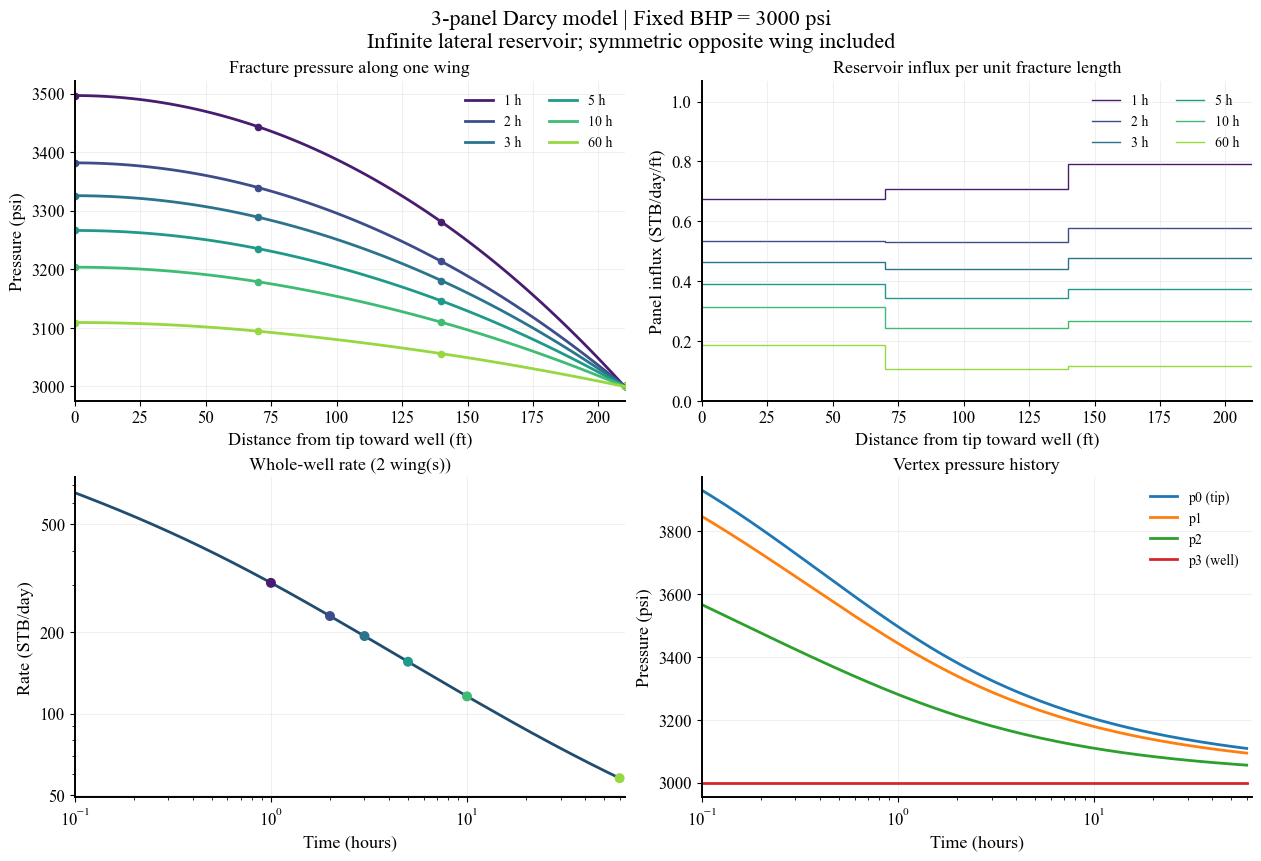

In [9]:
# 图像、所有时间步、指定时间结果、实际矩阵都会保存在 results 文件夹。
figure = save_results(solution, directory="results")
display(figure)
import matplotlib.pyplot as plt
plt.close(figure)

固定井底压力时，随储层压力扩散，总产量下降；$p_3$ 始终保持 3000 psi，其余节点压力逐渐降低。不同 panel 的入流份额也在改变：本例早期近井 panel 较强，较晚时尖端 panel 的贡献份额增加。

主图历史窗口从首个输出时刻的 1/10 开始，即默认 0.1 h。更早的启动区间保存在 CSV 中，下面解释其粗网格误差。

## 7. 对照原图，检查某一个时刻的实际矩阵

下面显示第一个输出时刻的 $\mathbf M$、$\mathbf b$ 和 $\mathbf x$。为了便于阅读，这里转换成 psi、STB/day、ft；求解器内部用 SI。

注意输出时刻为 1 h，但 $A$ 使用的是到达该时刻的最后一个内部时间步 $\Delta t$。此前的影响已经在 $H$ 中，不能把 $A(\Delta t)$ 改回 $A(1\ \mathrm h)$。

In [10]:
M, b, x = system_at_report(solution, report_number=1, field_units=True)
matrix_table = pd.DataFrame(M, index=equation_names(parameters.n_panels),
                            columns=unknown_names(parameters.n_panels))
matrix_table["rhs_b"] = b
display(matrix_table.round(4))
display(pd.DataFrame({"unknown": unknown_names(parameters.n_panels), "value": x}).round(6))

k = solution.report_indices[0]
dt_h = (solution.edges_s[k+1] - solution.edges_s[k]) / HOUR
print(f"输出时刻 = {solution.time_h[k]:g} h；当前内部步长 = {dt_h:.6g} h")
display(pd.DataFrame({
    "panel": np.arange(1, parameters.n_panels+1),
    "history_drawdown_psi": solution.history_pa[k] / PSI,
    "Darcy_center_pressure_psi": solution.center_darcy_pa[k] / PSI,
    "Green_center_pressure_psi": solution.center_reservoir_pa[k] / PSI,
}).round(6))

,p0,p1,p2,p3,qf1,qf2,qf3,Q1,Q2,Q3,rhs_b
tip_Q1_zero,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
continuity_node_1,0.0,0.0,0.0,0.0,-70.0000,0.0000,0.0000,-1.0000,1.0000,0.0000,0.0000
continuity_node_2,0.0,0.0,0.0,0.0,0.0000,-70.0000,0.0000,0.0000,-1.0000,1.0000,0.0000
well_control,0.0,0.0,0.0,1.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3000.0000
Darcy_panel_1,1.0,-1.0,0.0,0.0,-79.0602,0.0000,0.0000,-2.2589,0.0000,0.0000,0.0000
Darcy_panel_2,0.0,1.0,-1.0,0.0,0.0000,-79.0602,0.0000,0.0000,-2.2589,0.0000,0.0000
Darcy_panel_3,0.0,0.0,1.0,-1.0,0.0000,0.0000,-79.0602,0.0000,0.0000,-2.2589,0.0000
center_coupling_1,1.0,0.0,0.0,0.0,123.3572,0.0000,0.0000,-1.1294,0.0000,0.0000,3447.6069
center_coupling_2,0.0,1.0,0.0,0.0,0.0000,123.3572,0.0000,0.0000,-1.1294,0.0000,3362.9301
center_coupling_3,0.0,0.0,1.0,0.0,0.0000,0.0000,123.3572,0.0000,0.0000,-1.1294,3200.8223


,unknown,value
0,p0,3381.871428
1,p1,3339.741288
2,p2,3213.617783
3,p3,3000.000000
4,qf1,0.532887
5,qf2,0.529511
6,qf3,0.577169
7,Q1,0.000000
8,Q2,37.302091
9,Q3,74.367853


输出时刻 = 1 h；当前内部步长 = 0.00915609 h


,panel,history_drawdown_psi,Darcy_center_pressure_psi,Green_center_pressure_psi
0,1,656.879772,3483.525533,3483.525533
1,2,760.788657,3376.399839,3376.399839
2,3,973.688265,3156.214605,3156.214605


## 8. 检查守恒与压力匹配，并区分数值残差和离散误差

残差小表示线性方程解得准确，不等于网格已经足够细。

独立验证（`validate_model.py`，详细记录在 `validation.json`）包含：

- 对 $A_{ij}$ 做独立数值积分；检查自作用项和镜像项。
- 验证恒定流量下，多个时段的卷积能还原成 $A(t)q$。
- 用六个真实 panel 验证三 panel 加另一翼镜像的结果。
- 检查节点守恒、Darcy 压降和两个中心压力的一致性。
- 时间加密：60 → 120 点/十倍时间，所需时刻总产量最大变化 **0.32%**。
- 空间敏感性：3 → 12 个 panel/半翼，所需时刻总产量最大变化 **2.94%**；这还不是 12 网格已收敛的证明。

**实际发现的限制：** 三网格在最初几秒有局部负入流和节点压力高于初压的启动振荡。这是粗空间离散的误差，不应解释为真实回流。代码没有强行把负值改为零；保留原值并报告时间范围。本例 1–60 h 的所需输出时刻，所有 panel 入流均为正。若继续研究极早期，必须先做空间加密。

In [ ]:
checks = diagnostics(solution)
display(pd.DataFrame({"check": list(checks), "value": list(checks.values())}))
assert checks["max_scaled_linear_residual"] < 1e-12
assert checks["max_center_pressure_mismatch_psi"] < 1e-7
assert checks["max_continuity_relative_error"] < 1e-12
print("线性求解、中心压力匹配和节点守恒检查通过。")

,check,value
0,internal_time_steps,4.730000e+02
1,eta_ft2_hour,1.464881e+02
2,Fcd,2.000000e+01
3,max_scaled_linear_residual,3.175250e-16
4,max_center_pressure_mismatch_psi,1.080615e-12
5,max_Darcy_mismatch_psi,8.104615e-13
6,max_continuity_relative_error,6.303451e-17
7,tip_rate_relative_error,0.000000e+00
8,max_well_balance_relative_error,2.521380e-16
9,minimum_vertex_pressure_psi,3.000000e+03


线性求解、中心压力匹配和节点守恒检查通过。


: 

: 

## 9. 改为论文 Table 1 的定产量条件

论文 Table 1 的工况给定整井 $q_o=25$ STB/day。只替换第四行：

$$Q_3+\ell q_{f3}=Q_{w,\mathrm{half}}=\frac{q_o B}{2},$$

实际数值需把 bbl/day 换算为 $\mathrm{m^3/s}$，代码会完成换算。此时 $p_3$ 是待求井底压力，不能再同时固定 $p_3=3000$ psi。

以下例子仍是二维无限域、每翼三网格，因此只是改用论文的产量条件，不应称为已完整复现论文曲线。

In [ ]:
from dataclasses import replace

rate_parameters = replace(parameters, control="rate", total_rate_stb_day=25.0)
rate_solution = simulate(rate_parameters, report_times_h)
rate_table = result_table(rate_solution)
display(rate_table[["time_h", "well_rate_total_STB_day", "p0_psi", "p3_psi"]].round(3))
# 如需输出第二组图和 CSV，可运行：
# rate_figure = save_results(rate_solution, "results_rate")

,time_h,well_rate_total_STB_day,p0_psi,p3_psi
0,1.0,25.0,4157.202,4117.909
1,2.0,25.0,4135.120,4094.884
2,3.0,25.0,4118.355,4077.600
3,5.0,25.0,4092.226,4050.783
4,10.0,25.0,4045.691,4003.234
5,60.0,25.0,3843.254,3797.649


: 

: 

## 10. 之后如何继续

先看懂 `step_response → assemble_system → simulate` 三个函数的联系，再把 `n_panels=3` 改成 6、12 或更多。矩阵自动扩展为 $(3N+1)\times(3N+1)$。正式比较论文图件时，还应按对应案例核对侧向边界和控制条件。

来源：Zhou, W., Banerjee, R., Poe, B., Spath, J., and Thambynayagam, M. (2014), *Semianalytical Production Simulation of Complex Hydraulic-Fracture Networks*, SPE Journal, pp. 6–18。储层时间/空间叠加对应 Eqs. (2)–(3)；Darcy 流和中心压力对应 Eqs. (4)、(6)；节点守恒对应 Eq. (7)；基础物性取自 Table 1；无限域解属于 Appendix A 所讨论的情形。本 notebook 为独立实现。